# This notebook is just for plotting of our paper's result #

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1. Plotting the FP/FN for section "Error Function Justification" ##

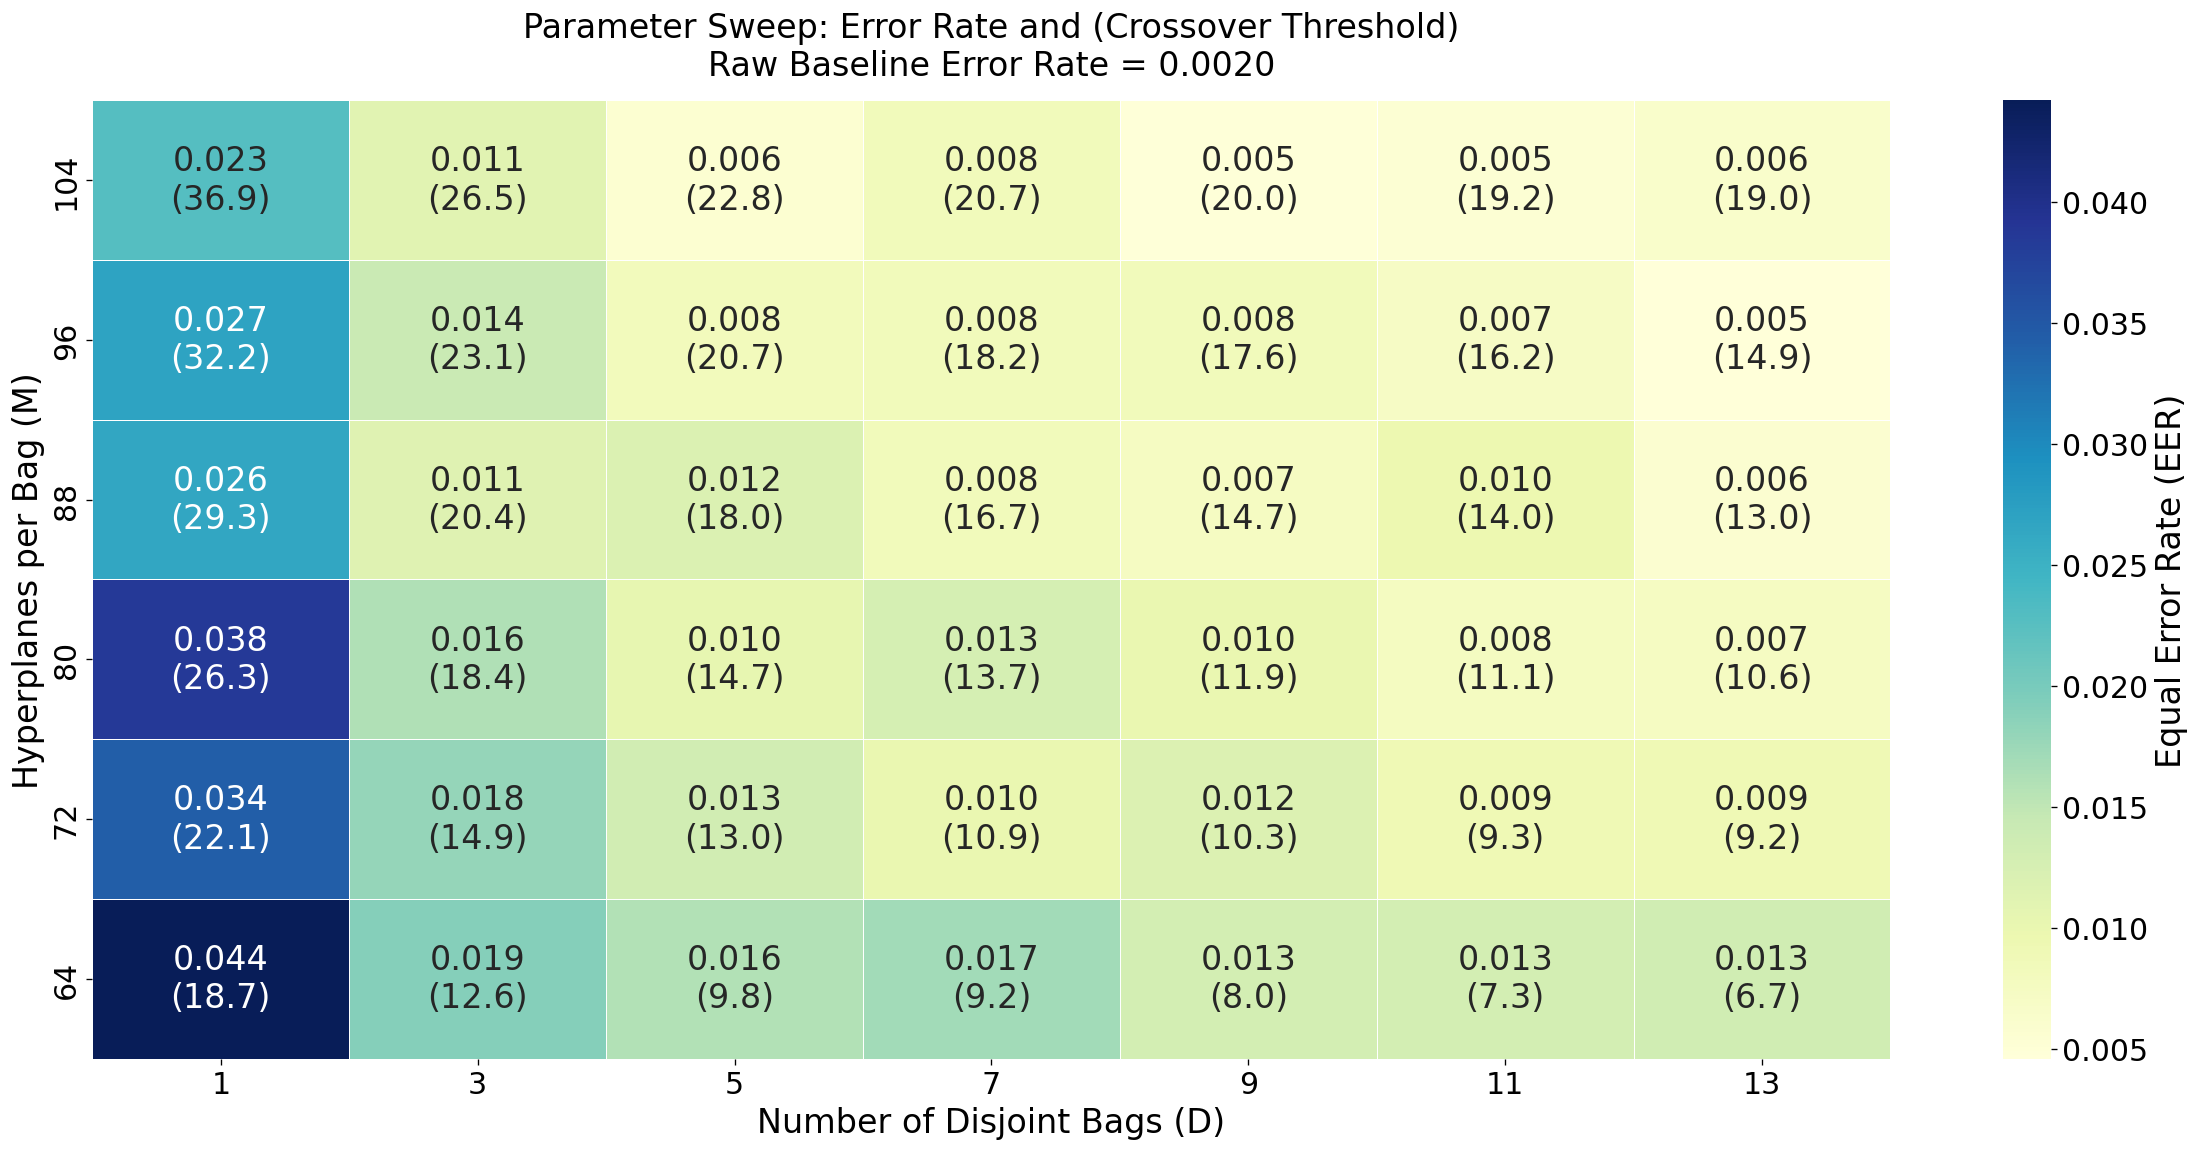

In [12]:
plt.rcParams.update({
    'font.size': 20,             # General font size
    'axes.titlesize': 20,        # Subplot title size
    'axes.labelsize': 20,        # X/Y axis label size
    'xtick.labelsize': 18,       # X axis numbers
    'ytick.labelsize': 18,       # Y axis numbers
    'legend.fontsize': 18,       # Legend text
    'legend.title_fontsize': 18, # Legend title
    'figure.titlesize': 30       # Master figure title
})

# 1. Load and prep the data
df = pd.read_csv("CCS26_Result - FP_FN_accuracy.csv")
raw_row = df[df['N'] == 'RAW']
raw_eer = float(raw_row['Rate'].iloc[0])

df_plot = df[df['N'] != 'RAW'].copy()
df_plot['N'] = df_plot['N'].astype(int)
df_plot['Bags'] = df_plot['Bags'].astype(int)
df_plot['Rate'] = df_plot['Rate'].astype(float)
df_plot['Hyperplane'] = df_plot['Hyperplane'].astype(float)

# =====================================================================
# FIGURE 1: THE ANNOTATED HEATMAP
# =====================================================================
plt.figure(figsize=(20, 10), dpi=120)

# Create 2D pivot tables for the grid
eer_grid = df_plot.pivot(index="N", columns="Bags", values="Rate")
thresh_grid = df_plot.pivot(index="N", columns="Bags", values="Hyperplane")

# Create custom text annotations: "EER \n (Threshold)"
annot_grid = np.empty(eer_grid.shape, dtype=object)
for i in range(eer_grid.shape[0]):
    for j in range(eer_grid.shape[1]):
        val_eer = eer_grid.iloc[i, j]
        val_thr = thresh_grid.iloc[i, j]
        annot_grid[i, j] = f"{val_eer:.3f}\n({val_thr:.1f})"

# Draw the heatmap (Using a cool/warm colormap where lower EER is cooler/better)
ax = sns.heatmap(eer_grid, annot=annot_grid, fmt="", cmap="YlGnBu", 
                 cbar_kws={'label': 'Equal Error Rate (EER)'}, linewidths=0.5)

ax.invert_yaxis() # Put lowest N at the bottom
plt.title(f"Parameter Sweep: Error Rate and (Crossover Threshold)\nRaw Baseline Error Rate = {raw_eer:.4f}", pad=15)
plt.xlabel("Number of Disjoint Bags (D)")
plt.ylabel("Hyperplanes per Bag (M)")
plt.tight_layout()

# Save as SVG. The 'bbox_inches="tight"' ensures no labels are cut off!
plt.savefig("pake_heatmap.svg", format="svg", bbox_inches="tight")

plt.show()

## 2. Plotting the Raw Baseline Result ##

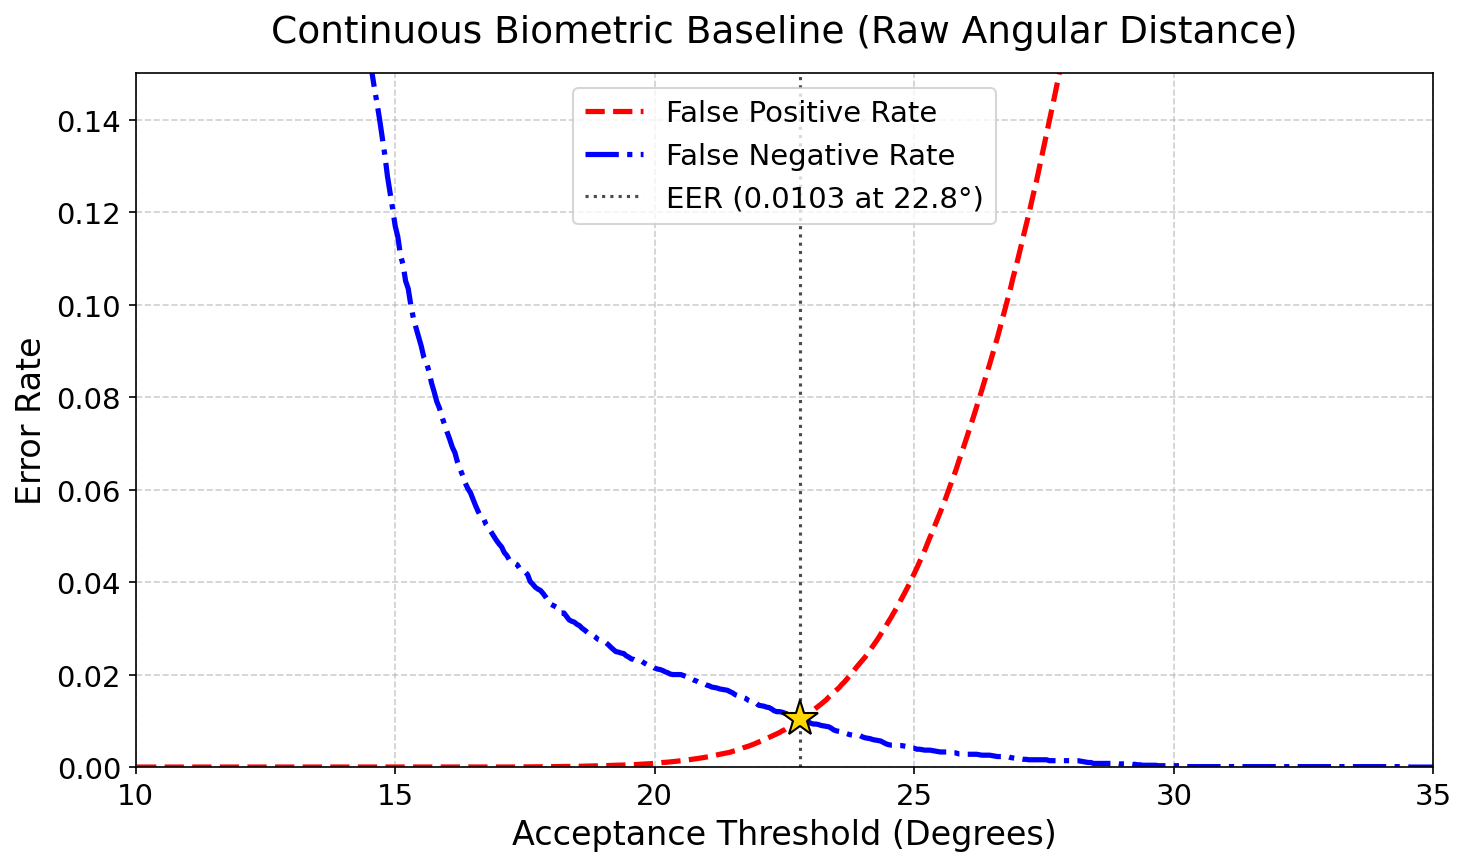

In [4]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})

# 1. Load the data from your CSV
df = pd.read_csv("raw_facial_FpFn.csv")

angle = df['Angle (Degrees)']
fp_rate = df['False Positive Rate']
fn_rate = df['False Negative Rate']

# 2. Find the exact Equal Error Rate (Crossover Point)
diff = np.abs(fp_rate - fn_rate)
min_idx = np.argmin(diff)

eer_angle = angle.iloc[min_idx]
eer_rate = (fp_rate.iloc[min_idx] + fn_rate.iloc[min_idx]) / 2

# 3. Create the Figure
plt.figure(figsize=(10, 6), dpi=150)

# Plot the FP and FN curves
plt.plot(angle, fp_rate, label="False Positive Rate", color='red', linestyle='--', linewidth=2.5)
plt.plot(angle, fn_rate, label="False Negative Rate", color='blue', linestyle='-.', linewidth=2.5)

# Plot the Crossover Star and the vertical EER line
plt.axvline(x=eer_angle, color='black', linestyle=':', alpha=0.7, label=f"EER ({eer_rate:.4f} at {eer_angle:.1f}°)")
plt.plot(eer_angle, eer_rate, marker='*', markersize=18, markeredgecolor='black', markerfacecolor='gold', zorder=5)

# 4. Formatting
plt.title("Continuous Biometric Baseline (Raw Angular Distance)", pad=15)
plt.xlabel("Acceptance Threshold (Degrees)")
plt.ylabel("Error Rate")

# --- THE ZOOM MECHANISM ---
# Since your EER is at ~22.7 degrees and ~0.011 rate, we constrain the axes 
# to strictly frame this intersection, cutting out the empty whitespace.
plt.xlim(10, 35)   # Focus the X-axis from 10 to 35 degrees
plt.ylim(0, 0.15)  # Focus the Y-axis from 0.0 to 0.15 error rate

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper center')

plt.tight_layout()

# Save perfectly crisp vector graphic for Overleaf
plt.savefig("raw_baseline_fp_fn.pdf", format="pdf", bbox_inches="tight")
plt.show()